In [35]:
import os
import random
import numpy as np

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# XGBoost
os.environ["OMP_NUM_THREADS"] = "1"      # tắt parallel non-determinism
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # nếu dùng GPU

print(f"✅ Global seed đã cố định: {SEED}")

✅ Global seed đã cố định: 42


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import holidays
import optuna
import logging
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import shap

optuna.logging.set_verbosity(logging.WARNING)
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
DATA_PATH = "sales.csv" 

TRAIN_START = "2012-07-04"
TRAIN_END   = "2022-12-31"
FORECAST_START = "2023-01-01"
FORECAST_END   = "2024-07-01"

TARGET_COL = "Revenue"
DATE_COL   = "date"

OPTIMAL_LAGS    = [1, 3, 7, 29, 30, 365]
OPTIMAL_WINDOWS = [3, 7]

# Ngày Tết Âm lịch
TET_DATES = {
    2012: '2012-01-23', 2013: '2013-02-10', 2014: '2014-01-31',
    2015: '2015-02-19', 2016: '2016-02-08', 2017: '2017-01-28',
    2018: '2018-02-16', 2019: '2019-02-05', 2020: '2020-01-25',
    2021: '2021-02-12', 2022: '2022-02-01', 2023: '2023-01-22',
    2024: '2024-02-10'
}
# ────────────────────────────────────────────────
# COGS CONFIG
# ────────────────────────────────────────────────
COGS_COL    = "COGS"

COGS_LAGS    = [1, 3, 7, 29, 30, 365]
COGS_WINDOWS = [3, 7]


In [ ]:
def load_data(path: str, date_col: str, target_col: str) -> pd.Series:
    df = pd.read_csv(path, parse_dates=[date_col])

    df.columns = df.columns.str.lower().str.strip()
    df = df.set_index(date_col.lower()).sort_index()
    series = df[target_col.lower()]
    series.name = "revenue"
    return series

raw_series = load_data(DATA_PATH, DATE_COL, TARGET_COL)
train_series = raw_series.loc[TRAIN_START:TRAIN_END]

print(f"📊 Tổng số ngày trong file gốc : {len(raw_series)}")
print(f"📊 Tập Train                   : {train_series.index.min().date()} → {train_series.index.max().date()} ({len(train_series)} ngày)")
print(f"📊 Giá trị trung bình Revenue  : {train_series.mean():,.0f}")
print(f"📊 Missing values              : {train_series.isnull().sum()}")

def load_data_col(path: str, date_col: str, target_col: str, col_name: str) -> pd.Series:
    """Tải một cột bất kỳ từ file, trả về Series với DatetimeIndex."""
    if path.endswith(".xlsx") or path.endswith(".xls"):
        df = pd.read_excel(path, parse_dates=[date_col])
    else:
        df = pd.read_csv(path, parse_dates=[date_col])
    df.columns = df.columns.str.lower().str.strip()
    df = df.set_index(date_col.lower()).sort_index()
    series = df[target_col.lower()]
    series.name = col_name
    return series

raw_cogs = load_data_col(DATA_PATH, DATE_COL, COGS_COL, "cogs")
train_cogs = raw_cogs.loc[TRAIN_START:TRAIN_END]

print(f"\n📊 COGS — Tổng số ngày : {len(raw_cogs)}")
print(f"📊 COGS Train          : {train_cogs.index.min().date()} → {train_cogs.index.max().date()} ({len(train_cogs)} ngày)")
print(f"📊 Giá trị trung bình COGS : {train_cogs.mean():,.0f}")
print(f"📊 Missing values COGS     : {train_cogs.isnull().sum()}")

📊 Tổng số ngày trong file gốc : 3833
📊 Tập Train                   : 2012-07-04 → 2022-12-31 (3833 ngày)
📊 Giá trị trung bình Revenue  : 4,286,584
📊 Missing values              : 0

📊 COGS — Tổng số ngày : 3833
📊 COGS Train          : 2012-07-04 → 2022-12-31 (3833 ngày)
📊 Giá trị trung bình COGS : 3,695,134
📊 Missing values COGS     : 0


In [39]:
def make_calendar_features(date_index: pd.DatetimeIndex) -> pd.DataFrame:
    """Tạo toàn bộ calendar + holiday features từ DatetimeIndex."""
    df = pd.DataFrame(index=date_index)

    # === Calendar ===
    df["dayofweek"]       = date_index.dayofweek
    df["quarter"]         = date_index.quarter
    df["month"]           = date_index.month
    df["year"]            = date_index.year
    df["dayofyear"]       = date_index.dayofyear
    df["dayofmonth"]      = date_index.day
    df["weekofyear"]      = date_index.isocalendar().week.values
    df["is_weekend"]      = (date_index.dayofweek >= 5).astype(int)
    df["is_month_start"]  = date_index.is_month_start.astype(int)
    df["is_month_end"]    = date_index.is_month_end.astype(int)
    df["is_quarter_start"]= date_index.is_quarter_start.astype(int)
    df["is_quarter_end"]  = date_index.is_quarter_end.astype(int)
    df["is_year_start"]   = date_index.is_year_start.astype(int)
    df["is_year_end"]     = date_index.is_year_end.astype(int)

    # === Cyclical ===
    df["sin_dayofweek"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["cos_dayofweek"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["sin_month"]     = np.sin(2 * np.pi * df["month"] / 12)
    df["cos_month"]     = np.cos(2 * np.pi * df["month"] / 12)

    # === Holidays (VN) ===
    years = date_index.year.unique().tolist()
    vn_holidays = holidays.VN(years=years)
    df["is_holiday"]    = date_index.map(lambda x: 1 if x in vn_holidays else 0)
    df["is_tet_season"] = date_index.map(lambda x: 1 if "Tet" in vn_holidays.get(x, "") else 0)

    # === Tết countdown ===
    def days_to_tet(date):
        tet_this = pd.to_datetime(TET_DATES.get(date.year))
        diff = (tet_this - date).days
        if diff < -7:
            tet_next = TET_DATES.get(date.year + 1)
            if tet_next:
                diff = (pd.to_datetime(tet_next) - date).days
        return diff

    df["days_to_tet"]  = pd.Series(date_index, index=date_index).apply(days_to_tet)
    df["is_pre_tet_3d"]= ((df["days_to_tet"] <= 3) & (df["days_to_tet"] > 0)).astype(int)

    return df

sample = make_calendar_features(pd.date_range("2023-01-20", periods=5, freq="D"))
print(f"✅ Calendar features — {sample.shape[1]} features:")
print(sample.columns.tolist())

✅ Calendar features — 22 features:
['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'is_year_start', 'is_year_end', 'sin_dayofweek', 'cos_dayofweek', 'sin_month', 'cos_month', 'is_holiday', 'is_tet_season', 'days_to_tet', 'is_pre_tet_3d']


In [40]:
def build_train_dataset(series: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
    """Tạo toàn bộ feature matrix cho tập train."""
    cal = make_calendar_features(series.index)

    # Lag features
    for lag in OPTIMAL_LAGS:
        cal[f"revenue_lag_{lag}"] = series.shift(lag).values

    # Rolling features (shift(1) trước để tránh leakage)
    for w in OPTIMAL_WINDOWS:
        shifted = series.shift(1)
        cal[f"revenue_roll_mean_{w}"] = shifted.rolling(w).mean().values
        cal[f"revenue_roll_std_{w}"]  = shifted.rolling(w).std().values
        cal[f"revenue_roll_max_{w}"]  = shifted.rolling(w).max().values
        cal[f"revenue_roll_min_{w}"]  = shifted.rolling(w).min().values

    cal.dropna(inplace=True)
    y = series.loc[cal.index]

    print(f"✅ Tập Train: {cal.shape[0]} mẫu × {cal.shape[1]} features")
    print(f"   Khoảng thời gian: {cal.index.min().date()} → {cal.index.max().date()}")
    return cal, y

X_train_full, y_train_full = build_train_dataset(train_series)

# ─── Build COGS train dataset  ───
def build_train_dataset_cogs(series: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
    """Feature matrix cho COGS — cấu trúc giống Revenue."""
    cal = make_calendar_features(series.index)

    for lag in COGS_LAGS:
        cal[f"cogs_lag_{lag}"] = series.shift(lag).values

    for w in COGS_WINDOWS:
        shifted = series.shift(1)
        cal[f"cogs_roll_mean_{w}"] = shifted.rolling(w).mean().values
        cal[f"cogs_roll_std_{w}"]  = shifted.rolling(w).std().values
        cal[f"cogs_roll_max_{w}"]  = shifted.rolling(w).max().values
        cal[f"cogs_roll_min_{w}"]  = shifted.rolling(w).min().values

    cal.dropna(inplace=True)
    y = series.loc[cal.index]

    print(f"✅ COGS Train: {cal.shape[0]} mẫu × {cal.shape[1]} features")
    print(f"   Khoảng thời gian: {cal.index.min().date()} → {cal.index.max().date()}")
    return cal, y

X_cogs_train, y_cogs_train = build_train_dataset_cogs(train_cogs)


✅ Tập Train: 3468 mẫu × 36 features
   Khoảng thời gian: 2013-07-04 → 2022-12-31
✅ COGS Train: 3468 mẫu × 36 features
   Khoảng thời gian: 2013-07-04 → 2022-12-31


In [41]:
print("========== BẮT ĐẦU HYPERPARAMETER TUNING (REVENUE) ==========\n")

def objective(trial):
    param = {
        "n_estimators"       : 1000,
        "early_stopping_rounds": 50,
        "eval_metric"        : "rmse",
        "learning_rate"      : trial.suggest_float("learning_rate", 1e-4, 0.1, log=True),
        "max_depth"          : trial.suggest_int("max_depth", 3, 10),
        "min_child_weight"   : trial.suggest_int("min_child_weight", 1, 10),
        "subsample"          : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree"   : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma"              : trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "reg_lambda"         : trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "reg_alpha"          : trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "random_state"       : 42,
        "tree_method"        : "hist"
    }

    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores, best_iters = [], []

    for train_idx, val_idx in tscv.split(X_train_full):
        Xt = X_train_full.iloc[train_idx]
        Xv = X_train_full.iloc[val_idx]
        yt = y_train_full.iloc[train_idx]
        yv = y_train_full.iloc[val_idx]

        m = xgb.XGBRegressor(**param)
        m.fit(Xt, yt, eval_set=[(Xv, yv)], verbose=False)
        preds = m.predict(Xv)
        cv_scores.append(np.sqrt(mean_squared_error(yv, preds)))
        best_iters.append(m.best_iteration)

    trial.set_user_attr("best_iterations", best_iters)
    return np.mean(cv_scores)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n✅ Tuning hoàn thành. Best CV RMSE: {study.best_value:,.0f}")
print("Best Params:", study.best_params)

========== BẮT ĐẦU HYPERPARAMETER TUNING (REVENUE) ==========



  0%|          | 0/30 [00:00<?, ?it/s]


✅ Tuning hoàn thành. Best CV RMSE: 1,011,781
Best Params: {'learning_rate': 0.021534500892332355, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.6041073859028397, 'colsample_bytree': 0.9221534889950529, 'gamma': 2.539309952949155e-05, 'reg_lambda': 0.39909064972762726, 'reg_alpha': 0.011104016029372322}


In [42]:
best_params = study.best_params.copy()
best_n_estimators = int(np.mean(study.best_trial.user_attrs["best_iterations"]))

print(f"[+] n_estimators (avg best_iteration): {best_n_estimators}")
print(f"    best_iterations per fold          : {study.best_trial.user_attrs['best_iterations']}")

final_model = xgb.XGBRegressor(
    **best_params,
    n_estimators=best_n_estimators,
    random_state=42,
    tree_method="hist"
)

print("\nĐang huấn luyện Final Model trên toàn bộ tập Train (2012 → 2022)...")
final_model.fit(X_train_full, y_train_full, verbose=False)
print("✅ Huấn luyện hoàn tất!")

# --- Kiểm tra lại chất lượng trên chính tập train ---
train_preds = final_model.predict(X_train_full)
train_mae   = mean_absolute_error(y_train_full, train_preds)
train_rmse  = np.sqrt(mean_squared_error(y_train_full, train_preds))
train_mape  = mean_absolute_percentage_error(y_train_full, train_preds) * 100
train_r2    = r2_score(y_train_full, train_preds)
print(f"\n📊 Revenue — In-sample performance (sanity check):")
print(f"   MAE  = {train_mae:,.0f}")
print(f"   RMSE = {train_rmse:,.0f}")
print(f"   MAPE = {train_mape:.2f}%  |  R² = {train_r2:.4f}")

[+] n_estimators (avg best_iteration): 602
    best_iterations per fold          : [314, 493, 999]

Đang huấn luyện Final Model trên toàn bộ tập Train (2012 → 2022)...
✅ Huấn luyện hoàn tất!

📊 Revenue — In-sample performance (sanity check):
   MAE  = 396,310
   RMSE = 515,681
   MAPE = 12.53%  |  R² = 0.9623


In [43]:
print("\n========== BẮT ĐẦU HYPERPARAMETER TUNING (COGS) ==========\n")

def cogs_objective(trial):
    param = {
        "n_estimators"         : 1000,
        "early_stopping_rounds": 50,
        "eval_metric"          : "rmse",
        "learning_rate"        : trial.suggest_float("learning_rate", 1e-4, 0.1, log=True),
        "max_depth"            : trial.suggest_int("max_depth", 3, 10),
        "min_child_weight"     : trial.suggest_int("min_child_weight", 1, 10),
        "subsample"            : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree"     : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma"                : trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "reg_lambda"           : trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "reg_alpha"            : trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "random_state"         : 42,
        "tree_method"          : "hist"
    }

    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores, best_iters = [], []

    for train_idx, val_idx in tscv.split(X_cogs_train):
        Xt = X_cogs_train.iloc[train_idx]
        Xv = X_cogs_train.iloc[val_idx]
        yt = y_cogs_train.iloc[train_idx]
        yv = y_cogs_train.iloc[val_idx]

        m = xgb.XGBRegressor(**param)
        m.fit(Xt, yt, eval_set=[(Xv, yv)], verbose=False)
        preds = m.predict(Xv)
        cv_scores.append(np.sqrt(mean_squared_error(yv, preds)))
        best_iters.append(m.best_iteration)

    trial.set_user_attr("best_iterations", best_iters)
    return np.mean(cv_scores)

cogs_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
cogs_study.optimize(cogs_objective, n_trials=30, show_progress_bar=True)

print(f"\n✅ COGS Tuning hoàn thành. Best CV RMSE: {cogs_study.best_value:,.0f}")
print("Best Params COGS:", cogs_study.best_params)


========== BẮT ĐẦU HYPERPARAMETER TUNING (COGS) ==========



  0%|          | 0/30 [00:00<?, ?it/s]


✅ COGS Tuning hoàn thành. Best CV RMSE: 891,985
Best Params COGS: {'learning_rate': 0.020169999834875583, 'max_depth': 5, 'min_child_weight': 6, 'subsample': 0.5825487101158466, 'colsample_bytree': 0.7562329620375886, 'gamma': 0.00012694043765309925, 'reg_lambda': 0.8377205484397002, 'reg_alpha': 0.005691361824137141}


In [44]:
# ─── Train final COGS model ───
cogs_best_params = cogs_study.best_params.copy()
cogs_best_n_estimators = int(np.mean(cogs_study.best_trial.user_attrs["best_iterations"]))

print(f"\n[+] COGS n_estimators (avg best_iteration): {cogs_best_n_estimators}")

cogs_model = xgb.XGBRegressor(
    **cogs_best_params,
    n_estimators=cogs_best_n_estimators,
    random_state=42,
    tree_method="hist"
)

print("\nĐang huấn luyện Final COGS Model trên toàn bộ tập Train (2012 → 2022)...")
cogs_model.fit(X_cogs_train, y_cogs_train, verbose=False)
print("✅ Huấn luyện COGS hoàn tất!")

# ─── In-sample COGS metrics ───
cogs_train_preds = cogs_model.predict(X_cogs_train)
cogs_mae   = mean_absolute_error(y_cogs_train, cogs_train_preds)
cogs_rmse  = np.sqrt(mean_squared_error(y_cogs_train, cogs_train_preds))
cogs_mape  = mean_absolute_percentage_error(y_cogs_train, cogs_train_preds) * 100
cogs_r2    = r2_score(y_cogs_train, cogs_train_preds)
print(f"\n📊 COGS — In-sample performance (sanity check):")
print(f"   MAE  = {cogs_mae:,.0f}")
print(f"   RMSE = {cogs_rmse:,.0f}")
print(f"   MAPE = {cogs_mape:.2f}%  |  R² = {cogs_r2:.4f}")


[+] COGS n_estimators (avg best_iteration): 533

Đang huấn luyện Final COGS Model trên toàn bộ tập Train (2012 → 2022)...
✅ Huấn luyện COGS hoàn tất!

📊 COGS — In-sample performance (sanity check):
   MAE  = 378,951
   RMSE = 500,083
   MAPE = 13.50%  |  R² = 0.9506


# Chiến lược:
- "history" = toàn bộ dữ liệu thực tế (train) + các ngày đã dự báo trước đó
- Mỗi ngày forecast được tính theo thứ tự, lag và rolling window luôn được lấy từ history → không bao giờ bị leakage, không cần giá trị tương lai.

In [45]:
forecast_dates = pd.date_range(start=FORECAST_START, end=FORECAST_END, freq="D")
print(f"📅 Sẽ dự báo {len(forecast_dates)} ngày: {forecast_dates[0].date()} → {forecast_dates[-1].date()}")

# Khởi tạo history bằng toàn bộ dữ liệu thực tế
history = train_series.copy().astype(float)
history.name = "revenue"

forecast_values = []

max_lag = max(OPTIMAL_LAGS)      # = 365
max_window = max(OPTIMAL_WINDOWS) # = 7
lookback = max(max_lag, max_window) + 1  # số ngày history cần thiết để tính features

for i, forecast_date in enumerate(forecast_dates):
    # Lấy slice history đủ để tính lag/rolling (không cần toàn bộ, chỉ cần lookback ngày)
    hist_slice = history.iloc[-(lookback):]

    # Tạo calendar features cho ngày cần dự báo
    cal_day = make_calendar_features(pd.DatetimeIndex([forecast_date]))

    # Tính lag features từ history
    for lag in OPTIMAL_LAGS:
        lag_date = forecast_date - pd.Timedelta(days=lag)
        cal_day[f"revenue_lag_{lag}"] = history.get(lag_date, np.nan)

    # Tính rolling features — dựa trên các ngày TRƯỚC forecast_date
    shifted = history  # shift(1) = dùng từ ngày trước ngày hiện tại
    for w in OPTIMAL_WINDOWS:
        # lấy w ngày kết thúc tại forecast_date - 1 (= shift(1))
        window_slice = history.loc[
            forecast_date - pd.Timedelta(days=w) : forecast_date - pd.Timedelta(days=1)
        ]
        cal_day[f"revenue_roll_mean_{w}"] = window_slice.mean() if len(window_slice) == w else np.nan
        cal_day[f"revenue_roll_std_{w}"]  = window_slice.std()  if len(window_slice) == w else np.nan
        cal_day[f"revenue_roll_max_{w}"]  = window_slice.max()  if len(window_slice) == w else np.nan
        cal_day[f"revenue_roll_min_{w}"]  = window_slice.min()  if len(window_slice) == w else np.nan

    # Sắp xếp cột đúng thứ tự như lúc train
    cal_day = cal_day.reindex(columns=X_train_full.columns)

    # Dự báo
    pred = float(final_model.predict(cal_day)[0])
    pred = max(pred, 0)  # Doanh thu không âm

    # Cập nhật history với giá trị vừa dự báo
    history.loc[forecast_date] = pred
    forecast_values.append(pred)

    if (i + 1) % 50 == 0 or (i + 1) == len(forecast_dates):
        print(f"  → Đã dự báo {i+1}/{len(forecast_dates)} ngày ... {forecast_date.date()} = {pred:,.0f}")

print("\n✅ Recursive forecasting hoàn tất!")

# ============================================================
# COGS — RECURSIVE FORECASTING (01/01/2023 → 01/07/2024)
# ============================================================
print("\n========== BẮT ĐẦU RECURSIVE FORECAST COGS ==========\n")
print(f"📅 Sẽ dự báo {len(forecast_dates)} ngày COGS: {forecast_dates[0].date()} → {forecast_dates[-1].date()}")

# Khởi tạo COGS history
cogs_history = train_cogs.copy().astype(float)
cogs_history.name = "cogs"

cogs_forecast_values = []

max_cogs_lag    = max(COGS_LAGS)
max_cogs_window = max(COGS_WINDOWS)
cogs_lookback   = max(max_cogs_lag, max_cogs_window) + 1

for i, forecast_date in enumerate(forecast_dates):
    cal_day = make_calendar_features(pd.DatetimeIndex([forecast_date]))

    for lag in COGS_LAGS:
        lag_date = forecast_date - pd.Timedelta(days=lag)
        cal_day[f"cogs_lag_{lag}"] = cogs_history.get(lag_date, np.nan)

    for w in COGS_WINDOWS:
        window_slice = cogs_history.loc[
            forecast_date - pd.Timedelta(days=w) : forecast_date - pd.Timedelta(days=1)
        ]
        cal_day[f"cogs_roll_mean_{w}"] = window_slice.mean() if len(window_slice) == w else np.nan
        cal_day[f"cogs_roll_std_{w}"]  = window_slice.std()  if len(window_slice) == w else np.nan
        cal_day[f"cogs_roll_max_{w}"]  = window_slice.max()  if len(window_slice) == w else np.nan
        cal_day[f"cogs_roll_min_{w}"]  = window_slice.min()  if len(window_slice) == w else np.nan

    cal_day = cal_day.reindex(columns=X_cogs_train.columns)

    cogs_pred = float(cogs_model.predict(cal_day)[0])
    cogs_pred = max(cogs_pred, 0)

    cogs_history.loc[forecast_date] = cogs_pred
    cogs_forecast_values.append(cogs_pred)

    if (i + 1) % 50 == 0 or (i + 1) == len(forecast_dates):
        print(f"  → Đã dự báo {i+1}/{len(forecast_dates)} ngày ... {forecast_date.date()} COGS = {cogs_pred:,.0f}")

print("\n✅ COGS Recursive forecasting hoàn tất!")

📅 Sẽ dự báo 548 ngày: 2023-01-01 → 2024-07-01
  → Đã dự báo 50/548 ngày ... 2023-02-19 = 3,442,320
  → Đã dự báo 100/548 ngày ... 2023-04-10 = 4,555,438
  → Đã dự báo 150/548 ngày ... 2023-05-30 = 9,175,322
  → Đã dự báo 200/548 ngày ... 2023-07-19 = 4,068,942
  → Đã dự báo 250/548 ngày ... 2023-09-07 = 2,952,321
  → Đã dự báo 300/548 ngày ... 2023-10-27 = 3,204,115
  → Đã dự báo 350/548 ngày ... 2023-12-16 = 1,972,584
  → Đã dự báo 400/548 ngày ... 2024-02-04 = 1,966,447
  → Đã dự báo 450/548 ngày ... 2024-03-25 = 4,810,001
  → Đã dự báo 500/548 ngày ... 2024-05-14 = 4,540,697
  → Đã dự báo 548/548 ngày ... 2024-07-01 = 5,774,526

✅ Recursive forecasting hoàn tất!

========== BẮT ĐẦU RECURSIVE FORECAST COGS ==========

📅 Sẽ dự báo 548 ngày COGS: 2023-01-01 → 2024-07-01
  → Đã dự báo 50/548 ngày ... 2023-02-19 COGS = 2,755,929
  → Đã dự báo 100/548 ngày ... 2023-04-10 COGS = 3,992,234
  → Đã dự báo 150/548 ngày ... 2023-05-30 COGS = 7,639,433
  → Đã dự báo 200/548 ngày ... 2023-07-19 C

In [46]:
OUTPUT_COMBINED = "submission.csv"

combined_df = pd.DataFrame({
    "date"   : forecast_dates,
    "revenue": [round(v, 2) for v in forecast_values],
    "cogs"   : [round(v, 2) for v in cogs_forecast_values],
})
combined_df["date"] = combined_df["date"].dt.strftime("%Y-%m-%d")

combined_df.to_csv(OUTPUT_COMBINED, index=False)

print(f"✅ Đã lưu file dự báo: {OUTPUT_COMBINED}")
print(f"   Số dòng      : {len(combined_df)}")
print(f"   Từ ngày      : {combined_df['date'].iloc[0]}")
print(f"   Đến ngày     : {combined_df['date'].iloc[-1]}")
print(f"   Revenue TB   : {combined_df['revenue'].mean():,.0f}")
print(f"   Revenue Min  : {combined_df['revenue'].min():,.0f}")
print(f"   Revenue Max  : {combined_df['revenue'].max():,.0f}")
print(f"   COGS TB      : {combined_df['cogs'].mean():,.0f}")
print(f"   COGS Min     : {combined_df['cogs'].min():,.0f}")
print(f"   COGS Max     : {combined_df['cogs'].max():,.0f}")

print("\n--- PREVIEW (10 dòng đầu) ---")
print(combined_df.head(10).to_string(index=False))
print("\n--- PREVIEW (10 dòng cuối) ---")
print(combined_df.tail(10).to_string(index=False))


✅ Đã lưu file dự báo: submission.csv
   Số dòng      : 548
   Từ ngày      : 2023-01-01
   Đến ngày     : 2024-07-01
   Revenue TB   : 3,856,356
   Revenue Min  : 1,291,235
   Revenue Max  : 10,161,999
   COGS TB      : 3,274,648
   COGS Min     : 1,055,771
   COGS Max     : 9,750,761

--- PREVIEW (10 dòng đầu) ---
      date    revenue       cogs
2023-01-01 2133327.50 1900970.00
2023-01-02 1766594.00 1716248.75
2023-01-03 1438798.38 1138870.25
2023-01-04 1351532.62 1099807.00
2023-01-05 1357380.50 1142383.88
2023-01-06 1462364.50 1150722.75
2023-01-07 1557628.50 1267164.62
2023-01-08 1714139.88 1479763.75
2023-01-09 1883856.00 1576703.75
2023-01-10 2032262.75 1629093.50

--- PREVIEW (10 dòng cuối) ---
      date   revenue      cogs
2024-06-22 4258727.5 3925169.0
2024-06-23 4801477.0 4342651.5
2024-06-24 4993384.0 4604917.0
2024-06-25 5313749.0 4931288.5
2024-06-26 6167891.0 5348529.5
2024-06-27 6411436.0 5359156.5
2024-06-28 6160830.0 5537819.5
2024-06-29 5689106.0 4989381.5
2024-06-3

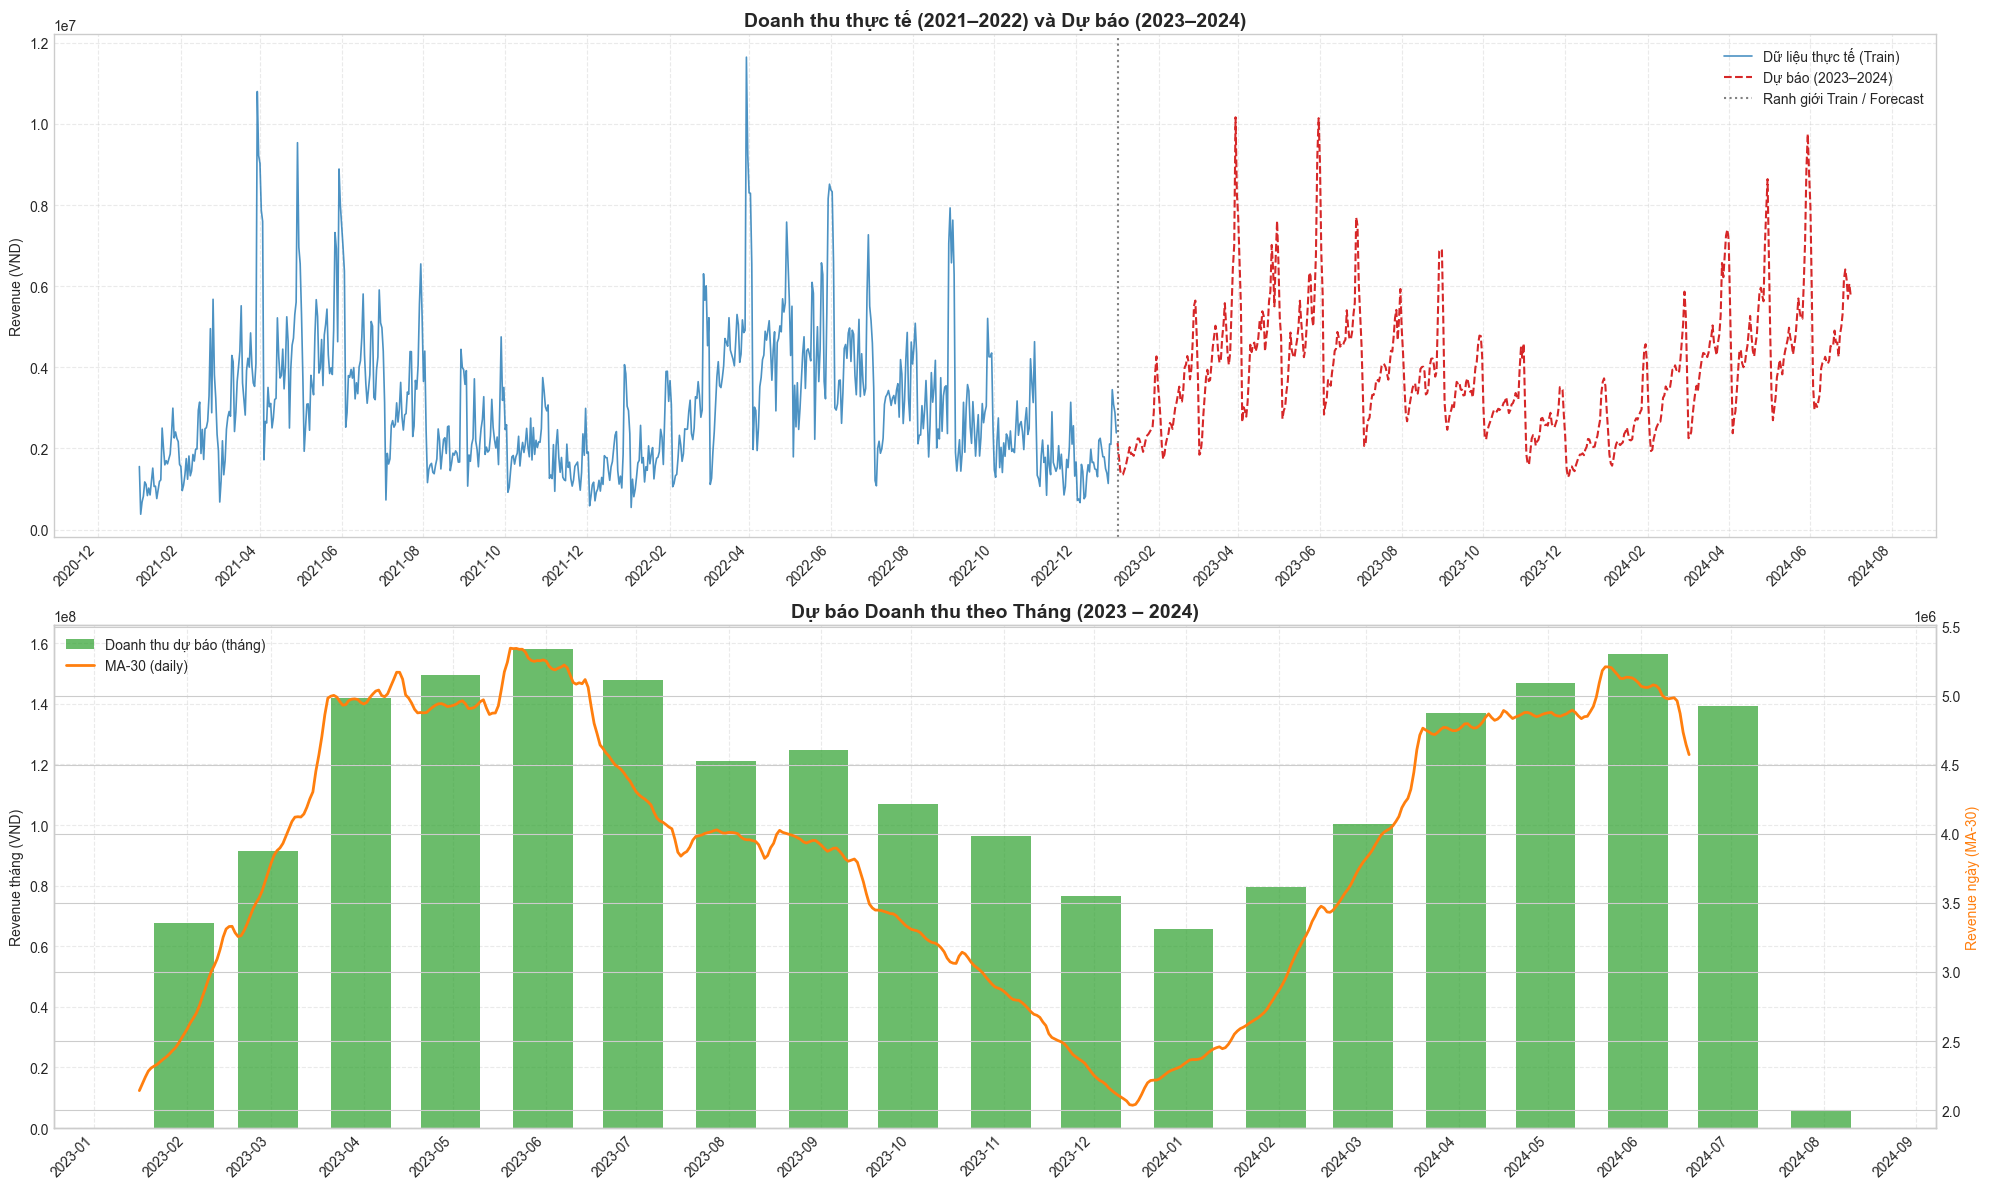

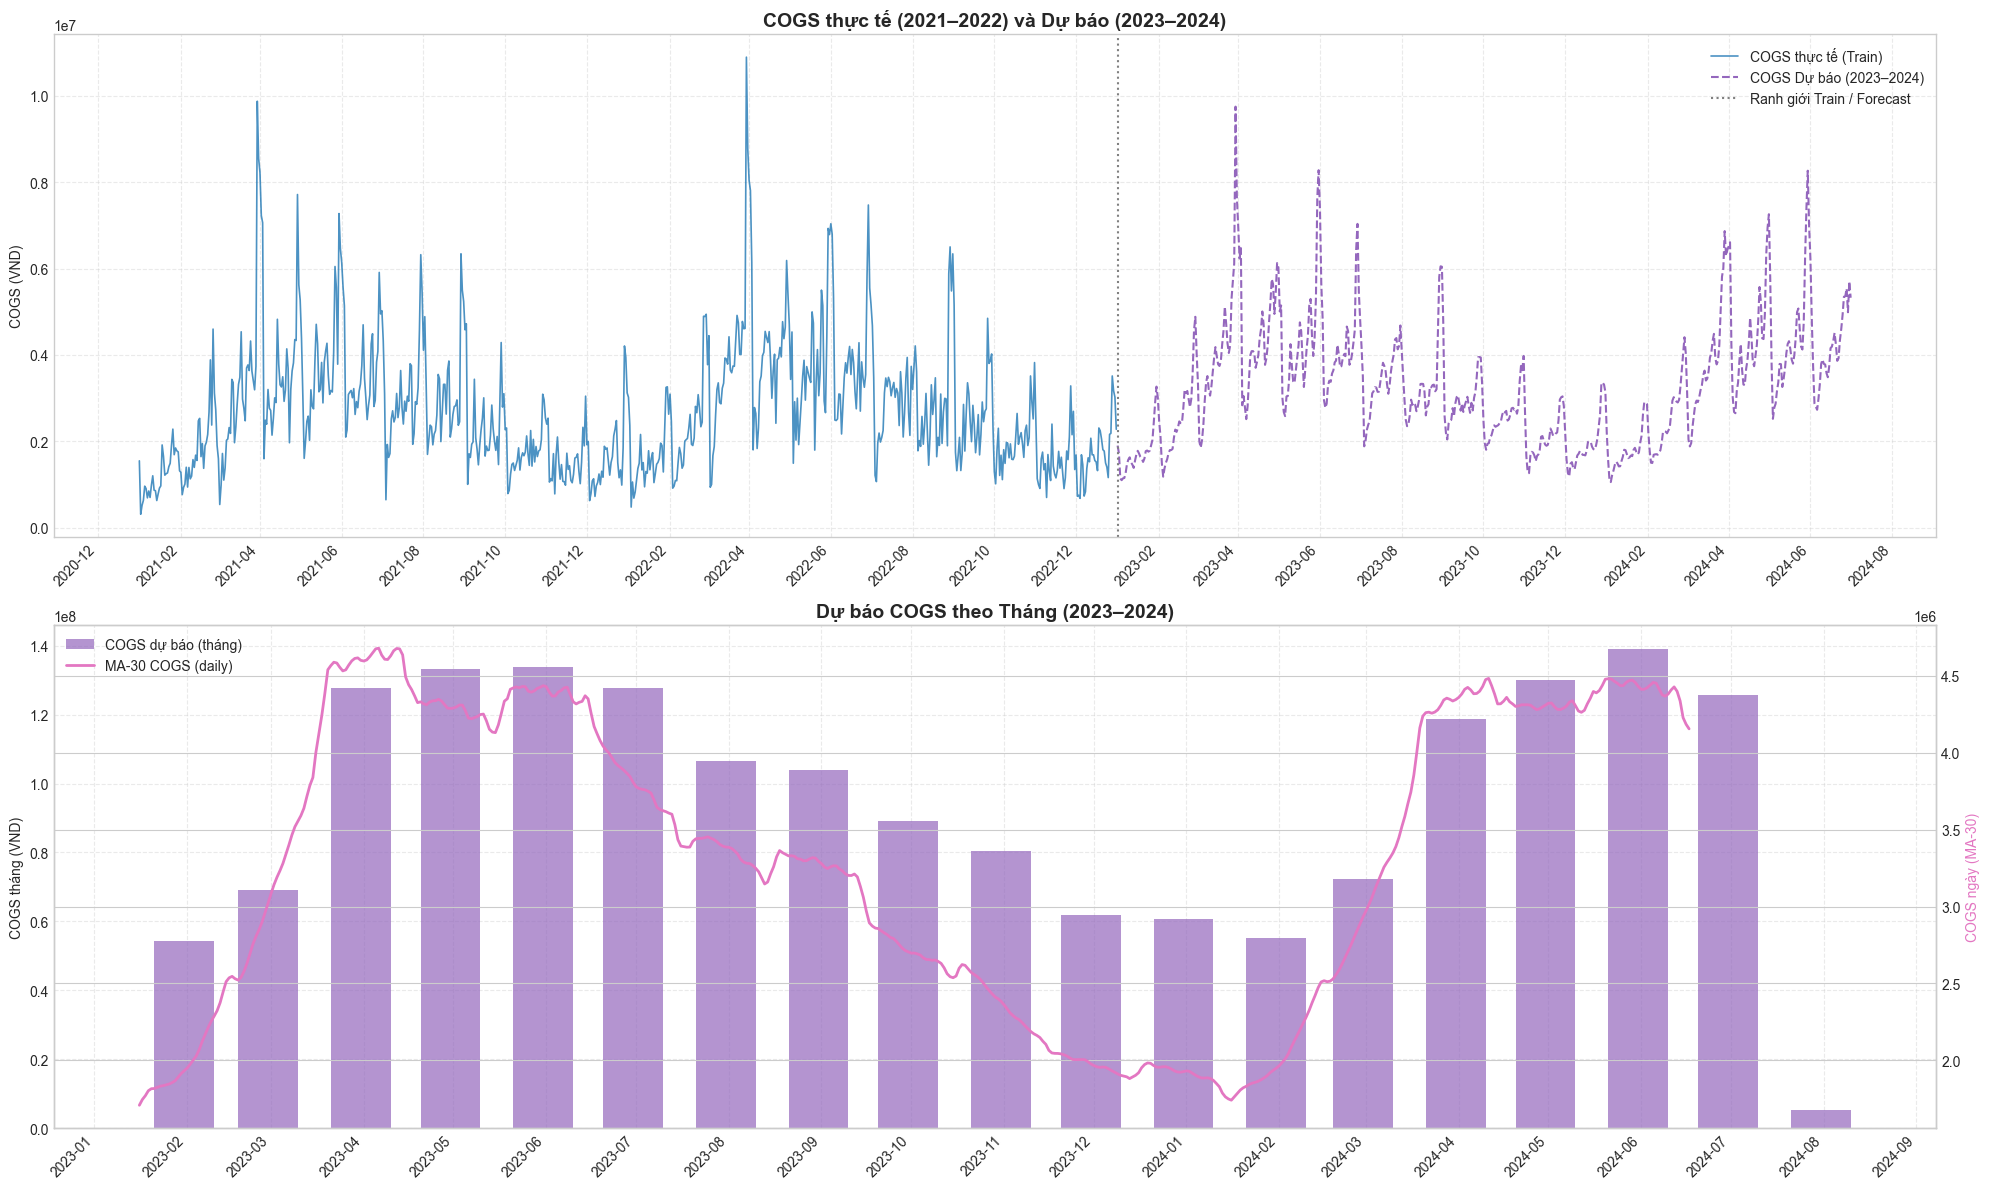

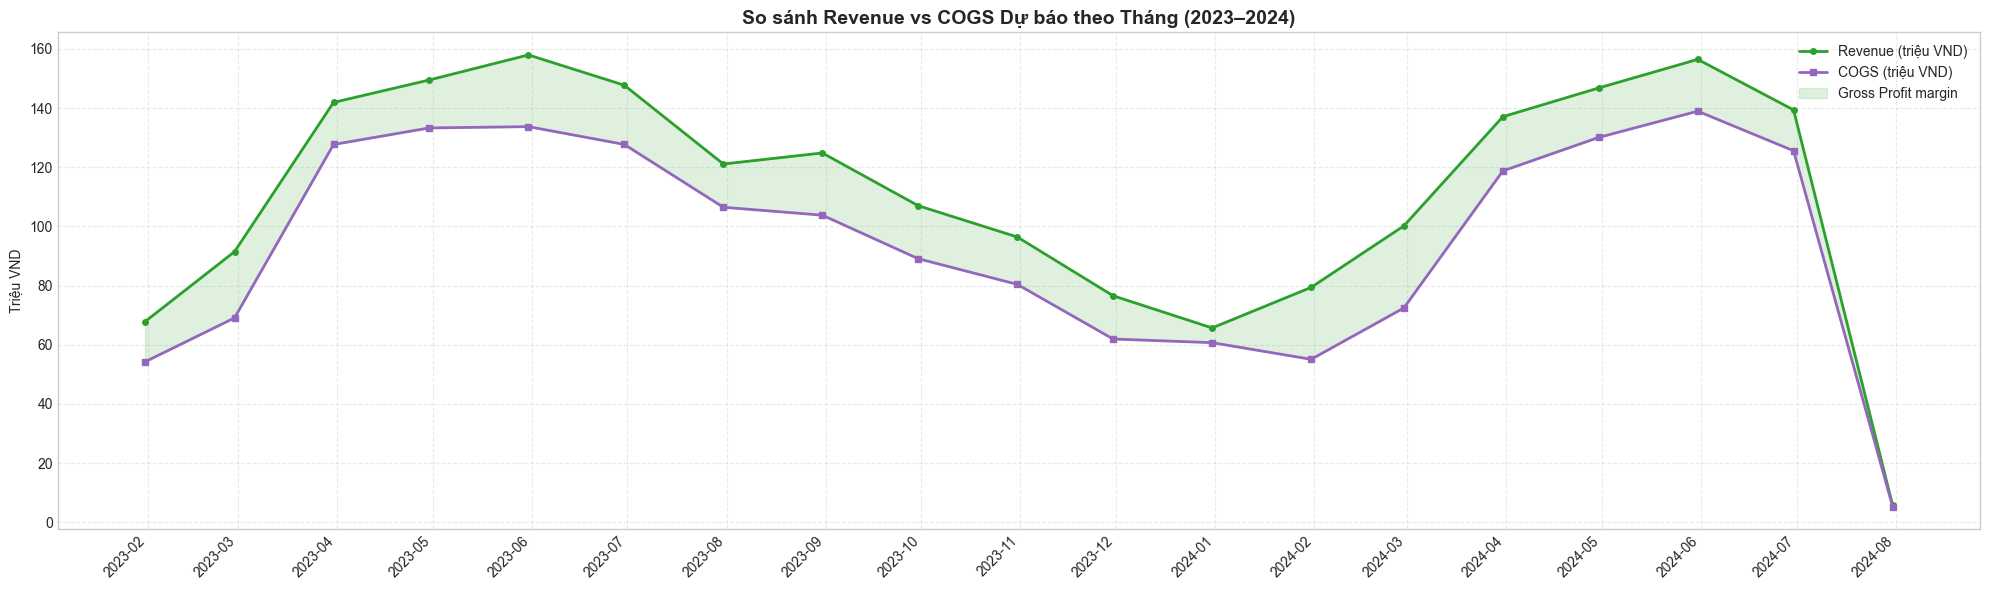

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(20, 12))

# --- Biểu đồ 1: Tổng quan Train + Forecast ---
ax1 = axes[0]
# Vẽ năm cuối train (2022) để có context
train_tail = train_series.loc["2021":]
ax1.plot(train_tail.index, train_tail.values,
         color="#1f77b4", linewidth=1.2, label="Dữ liệu thực tế (Train)", alpha=0.8)

forecast_series = pd.Series(
    forecast_values,
    index=forecast_dates,
    name="revenue"
)
ax1.plot(forecast_series.index, forecast_series.values,
         color="#d62728", linewidth=1.5, label="Dự báo (2023–2024)", linestyle="--")

ax1.axvline(x=pd.to_datetime(FORECAST_START), color="gray", linestyle=":", linewidth=1.5,
            label="Ranh giới Train / Forecast")

ax1.set_title("Doanh thu thực tế (2021–2022) và Dự báo (2023–2024)", fontsize=14, fontweight="bold")
ax1.set_ylabel("Revenue (VND)")
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.4)

# --- Biểu đồ 2: Chỉ phần Forecast chi tiết ---
ax2 = axes[1]
forecast_monthly = forecast_series.resample("M").sum()
ax2.bar(forecast_monthly.index, forecast_monthly.values,
        width=20, color="#2ca02c", alpha=0.7, label="Doanh thu dự báo (tháng)")

# Đường trung bình động 30 ngày
rolling_30 = forecast_series.rolling(30, center=True).mean()
ax2_twin = ax2.twinx()
ax2_twin.plot(rolling_30.index, rolling_30.values,
              color="#ff7f0e", linewidth=2, label="MA-30 (daily)")
ax2_twin.set_ylabel("Revenue ngày (MA-30)", color="#ff7f0e")

ax2.set_title("Dự báo Doanh thu theo Tháng (2023 – 2024)", fontsize=14, fontweight="bold")
ax2.set_ylabel("Revenue tháng (VND)")
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ─── Biểu đồ COGS: Tổng quan + Tháng ───
cogs_forecast_series = pd.Series(
    cogs_forecast_values,
    index=forecast_dates,
    name="cogs"
)

fig2, axes2 = plt.subplots(2, 1, figsize=(20, 12))

ax1c = axes2[0]
train_cogs_tail = train_cogs.loc["2021":]
ax1c.plot(train_cogs_tail.index, train_cogs_tail.values,
          color="#1f77b4", linewidth=1.2, label="COGS thực tế (Train)", alpha=0.8)
ax1c.plot(cogs_forecast_series.index, cogs_forecast_series.values,
          color="#9467bd", linewidth=1.5, label="COGS Dự báo (2023–2024)", linestyle="--")
ax1c.axvline(x=pd.to_datetime(FORECAST_START), color="gray", linestyle=":", linewidth=1.5,
             label="Ranh giới Train / Forecast")
ax1c.set_title("COGS thực tế (2021–2022) và Dự báo (2023–2024)", fontsize=14, fontweight="bold")
ax1c.set_ylabel("COGS (VND)")
ax1c.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1c.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax1c.get_xticklabels(), rotation=45, ha="right")
ax1c.legend()
ax1c.grid(True, linestyle="--", alpha=0.4)

ax2c = axes2[1]
cogs_monthly = cogs_forecast_series.resample("M").sum()
ax2c.bar(cogs_monthly.index, cogs_monthly.values,
         width=20, color="#9467bd", alpha=0.7, label="COGS dự báo (tháng)")
cogs_rolling_30 = cogs_forecast_series.rolling(30, center=True).mean()
ax2c_twin = ax2c.twinx()
ax2c_twin.plot(cogs_rolling_30.index, cogs_rolling_30.values,
               color="#e377c2", linewidth=2, label="MA-30 COGS (daily)")
ax2c_twin.set_ylabel("COGS ngày (MA-30)", color="#e377c2")
ax2c.set_title("Dự báo COGS theo Tháng (2023–2024)", fontsize=14, fontweight="bold")
ax2c.set_ylabel("COGS tháng (VND)")
ax2c.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2c.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax2c.get_xticklabels(), rotation=45, ha="right")
lines1c, labels1c = ax2c.get_legend_handles_labels()
lines2c, labels2c = ax2c_twin.get_legend_handles_labels()
ax2c.legend(lines1c + lines2c, labels1c + labels2c, loc="upper left")
ax2c.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ─── Biểu đồ so sánh Revenue vs COGS ───
fig3, ax = plt.subplots(figsize=(20, 6))
rev_monthly = pd.Series(forecast_values, index=forecast_dates).resample("M").sum()
ax.plot(rev_monthly.index, rev_monthly.values / 1e6,
        color="#2ca02c", linewidth=2, marker="o", markersize=4, label="Revenue (triệu VND)")
ax.plot(cogs_monthly.index, cogs_monthly.values / 1e6,
        color="#9467bd", linewidth=2, marker="s", markersize=4, label="COGS (triệu VND)")
ax.fill_between(rev_monthly.index,
                cogs_monthly.values / 1e6,
                rev_monthly.values / 1e6,
                alpha=0.15, color="#2ca02c", label="Gross Profit margin")
ax.set_title("So sánh Revenue vs COGS Dự báo theo Tháng (2023–2024)", fontsize=14, fontweight="bold")
ax.set_ylabel("Triệu VND")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

C:\Users\TGDD-GAMING\AppData\Local\Temp\ipykernel_20660\1803921466.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_rev, X_sample_rev, show=False, max_display=20)


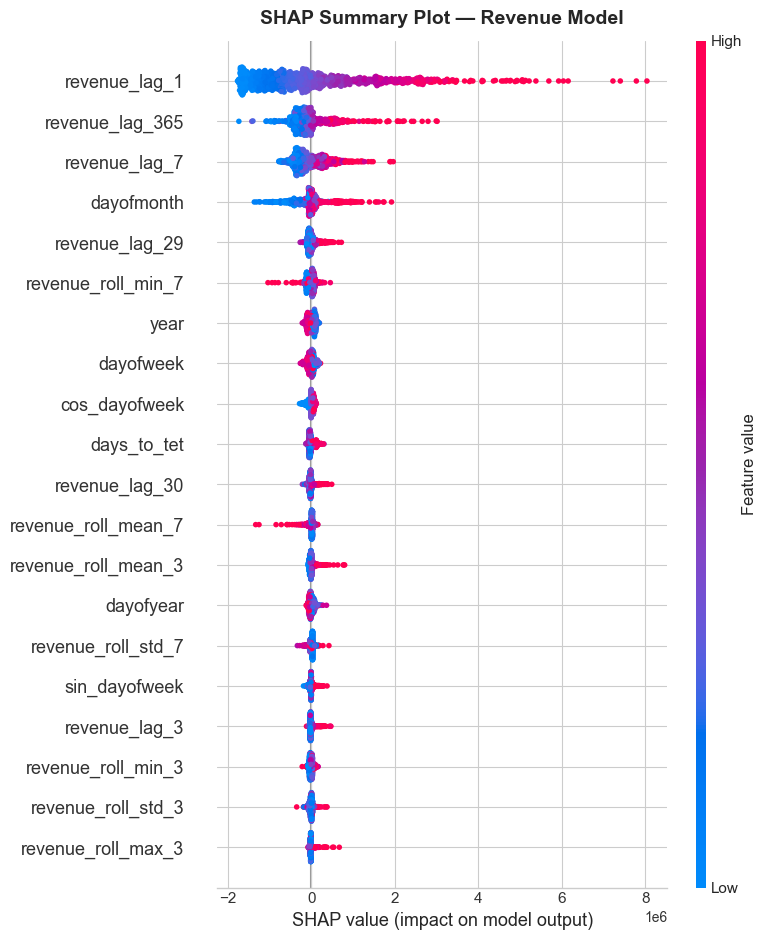

C:\Users\TGDD-GAMING\AppData\Local\Temp\ipykernel_20660\1803921466.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_rev, X_sample_rev, plot_type="bar", show=False, max_display=20)


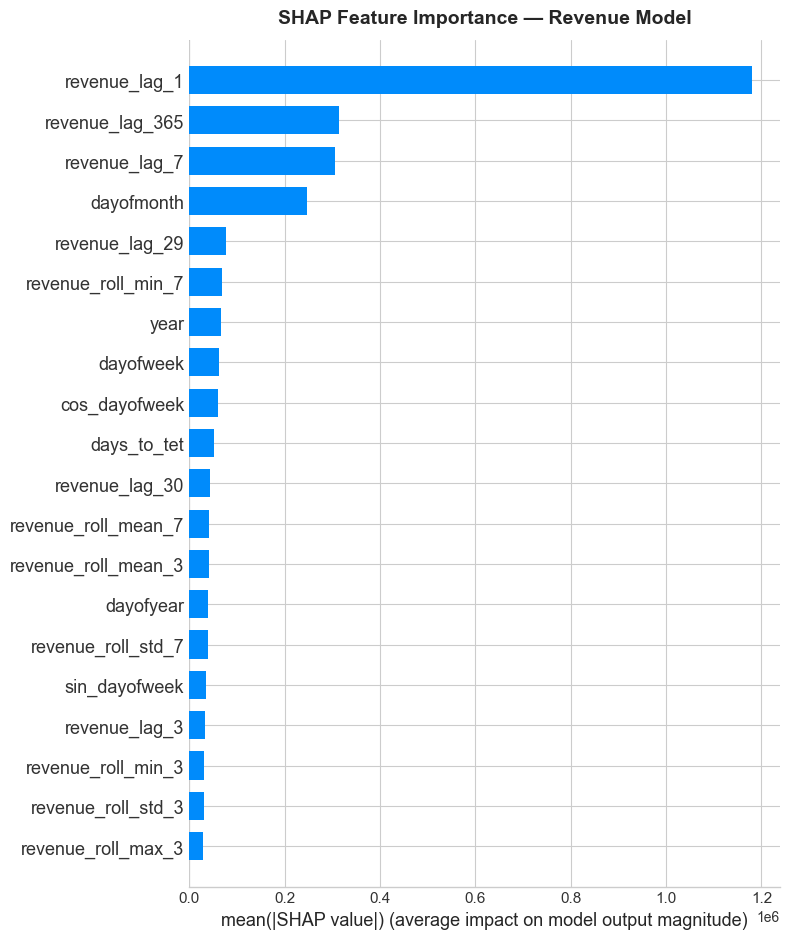

🔝 Top 5 features (Revenue): ['revenue_lag_1', 'revenue_lag_365', 'revenue_lag_7', 'dayofmonth', 'revenue_lag_29']


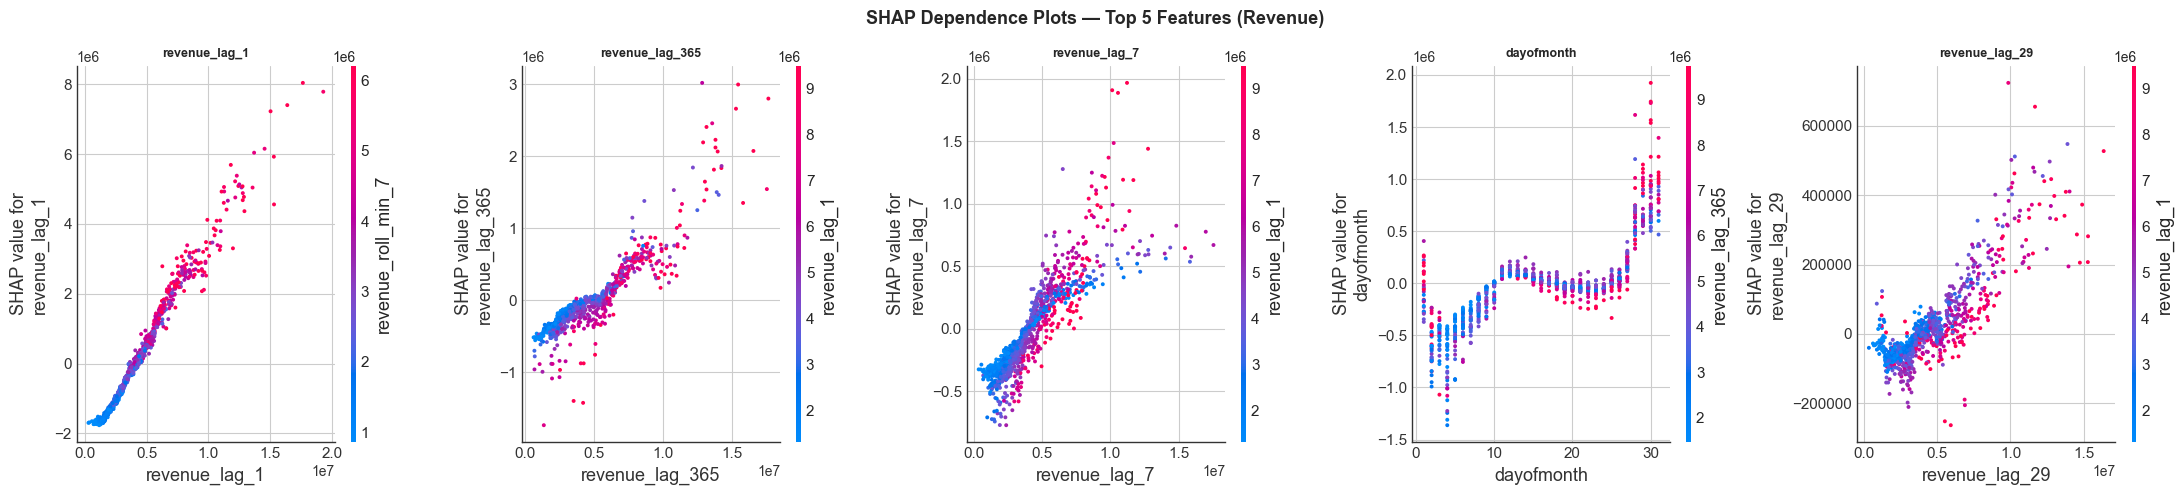


📊 Top-20 Feature Importance — Revenue (mean |SHAP|):
---------------------------------------------
   1. revenue_lag_1                       1,179,838.25
   2. revenue_lag_365                     313,722.22
   3. revenue_lag_7                       305,389.03
   4. dayofmonth                          247,940.36
   5. revenue_lag_29                       76,398.68
   6. revenue_roll_min_7                   68,573.35
   7. year                                 67,158.04
   8. dayofweek                            62,363.73
   9. cos_dayofweek                        60,063.49
  10. days_to_tet                          52,763.33
  11. revenue_lag_30                       43,358.39
  12. revenue_roll_mean_7                  41,989.45
  13. revenue_roll_mean_3                  40,998.17
  14. dayofyear                            40,205.03
  15. revenue_roll_std_7                   38,638.68
  16. sin_dayofweek                        34,515.62
  17. revenue_lag_3                        33,547.

In [48]:
explainer_rev = shap.TreeExplainer(final_model)

sample_size = min(1000, len(X_train_full))
X_sample_rev = X_train_full.sample(n=sample_size, random_state=42)
shap_values_rev = explainer_rev.shap_values(X_sample_rev)

# ── Summary Plot (Beeswarm) ──
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_rev, X_sample_rev, show=False, max_display=20)
plt.title("SHAP Summary Plot — Revenue Model", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── Bar Plot (mean |SHAP|) ──
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_rev, X_sample_rev, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance — Revenue Model", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── Top-5 Dependence Plots ──
mean_abs_shap_rev = pd.Series(
    np.abs(shap_values_rev).mean(axis=0),
    index=X_sample_rev.columns
).sort_values(ascending=False)

top5_rev = mean_abs_shap_rev.head(5).index.tolist()
print(f"🔝 Top 5 features (Revenue): {top5_rev}")

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, feat in zip(axes, top5_rev):
    shap.dependence_plot(feat, shap_values_rev, X_sample_rev, ax=ax, show=False, dot_size=8)
    ax.set_title(feat, fontsize=9, fontweight="bold")
plt.suptitle("SHAP Dependence Plots — Top 5 Features (Revenue)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Bảng Top-20 ──
print("\n📊 Top-20 Feature Importance — Revenue (mean |SHAP|):")
print("-" * 45)
for rank, (feat, val) in enumerate(mean_abs_shap_rev.head(20).items(), 1):
    print(f"  {rank:>2}. {feat:<35} {val:>10,.2f}")

C:\Users\TGDD-GAMING\AppData\Local\Temp\ipykernel_20660\277404026.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_cogs, X_sample_cogs, show=False, max_display=20)


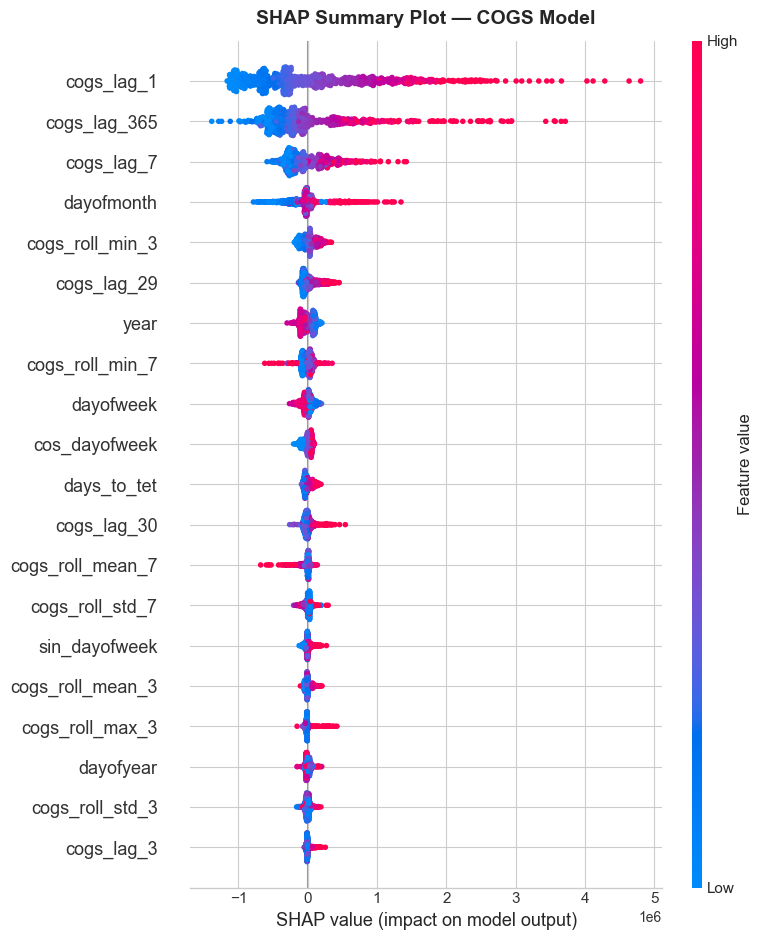

C:\Users\TGDD-GAMING\AppData\Local\Temp\ipykernel_20660\277404026.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_cogs, X_sample_cogs, plot_type="bar", show=False, max_display=20)


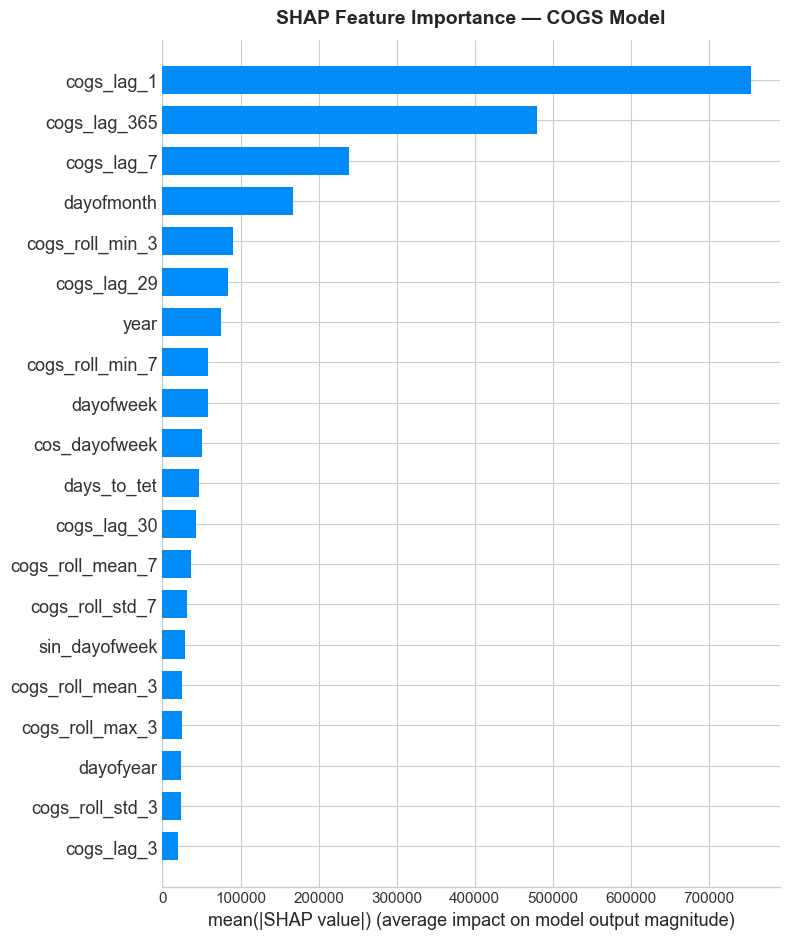

🔝 Top 5 features (COGS): ['cogs_lag_1', 'cogs_lag_365', 'cogs_lag_7', 'dayofmonth', 'cogs_roll_min_3']


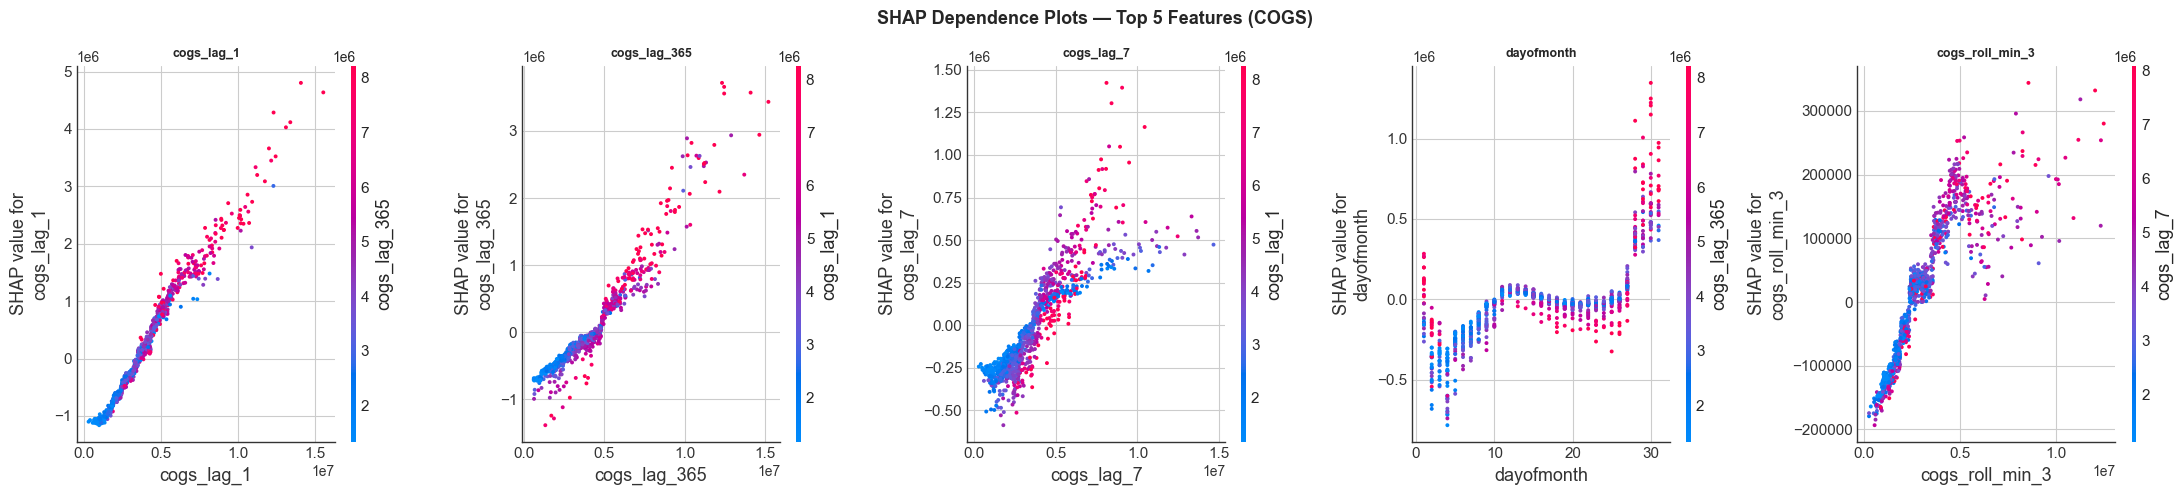


📊 Top-20 Feature Importance — COGS (mean |SHAP|):
---------------------------------------------
   1. cogs_lag_1                          753,415.81
   2. cogs_lag_365                        480,393.97
   3. cogs_lag_7                          239,575.08
   4. dayofmonth                          167,500.81
   5. cogs_roll_min_3                      90,029.40
   6. cogs_lag_29                          83,290.86
   7. year                                 75,128.45
   8. cogs_roll_min_7                      58,700.20
   9. dayofweek                            58,103.62
  10. cos_dayofweek                        50,534.14
  11. days_to_tet                          47,012.86
  12. cogs_lag_30                          43,162.24
  13. cogs_roll_mean_7                     36,137.49
  14. cogs_roll_std_7                      31,896.66
  15. sin_dayofweek                        28,699.77
  16. cogs_roll_mean_3                     25,561.01
  17. cogs_roll_max_3                      25,486.36
  

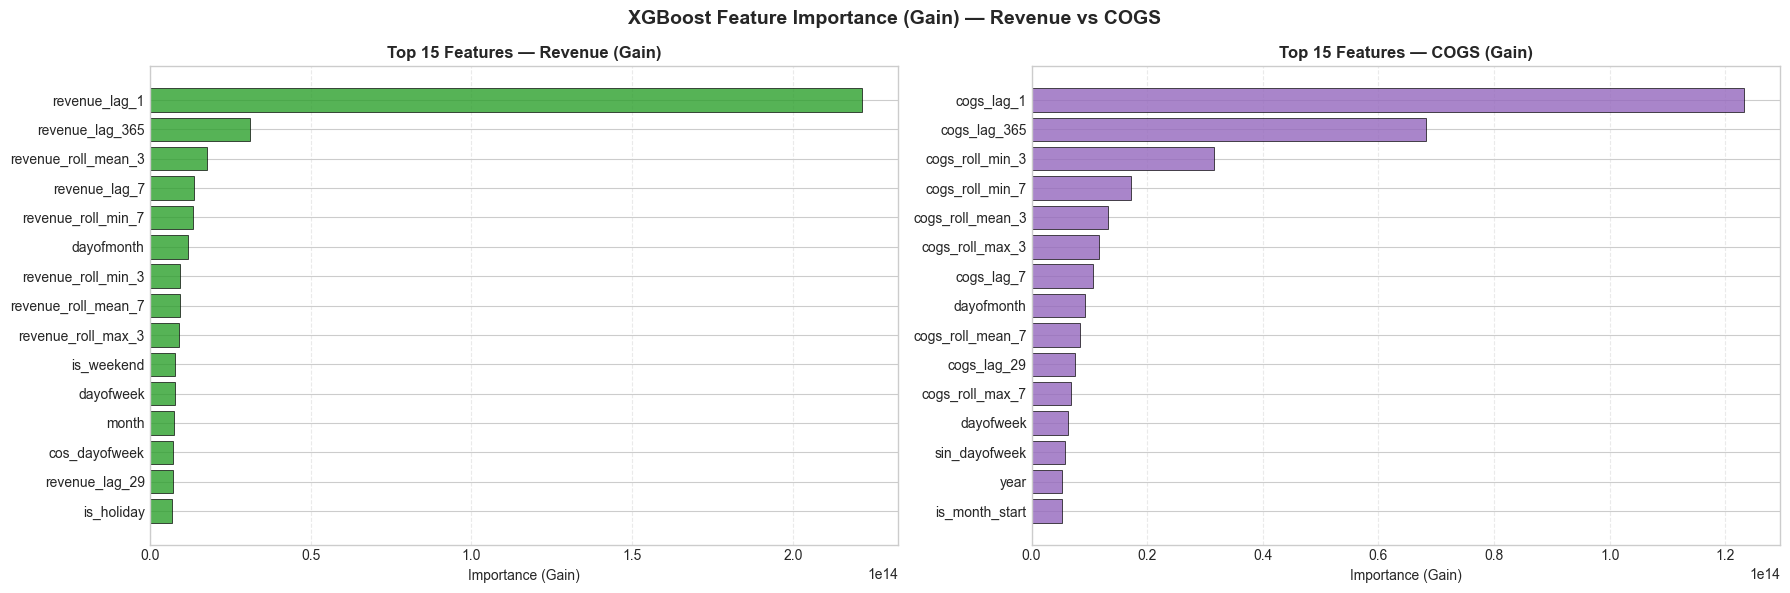

In [49]:
explainer_cogs = shap.TreeExplainer(cogs_model)

sample_size_c = min(1000, len(X_cogs_train))
X_sample_cogs = X_cogs_train.sample(n=sample_size_c, random_state=42)
shap_values_cogs = explainer_cogs.shap_values(X_sample_cogs)

# ── Summary Plot ──
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_cogs, X_sample_cogs, show=False, max_display=20)
plt.title("SHAP Summary Plot — COGS Model", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── Bar Plot ──
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_cogs, X_sample_cogs, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance — COGS Model", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── Top-5 Dependence Plots ──
mean_abs_shap_cogs = pd.Series(
    np.abs(shap_values_cogs).mean(axis=0),
    index=X_sample_cogs.columns
).sort_values(ascending=False)

top5_cogs = mean_abs_shap_cogs.head(5).index.tolist()
print(f"🔝 Top 5 features (COGS): {top5_cogs}")

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, feat in zip(axes, top5_cogs):
    shap.dependence_plot(feat, shap_values_cogs, X_sample_cogs, ax=ax, show=False, dot_size=8)
    ax.set_title(feat, fontsize=9, fontweight="bold")
plt.suptitle("SHAP Dependence Plots — Top 5 Features (COGS)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Bảng Top-20 ──
print("\n📊 Top-20 Feature Importance — COGS (mean |SHAP|):")
print("-" * 45)
for rank, (feat, val) in enumerate(mean_abs_shap_cogs.head(20).items(), 1):
    print(f"  {rank:>2}. {feat:<35} {val:>10,.2f}")

# ── So sánh XGBoost Gain Importance: Revenue vs COGS ──
rev_gain  = pd.Series(final_model.get_booster().get_score(importance_type="gain")).sort_values(ascending=False).head(15)
cogs_gain = pd.Series(cogs_model.get_booster().get_score(importance_type="gain")).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].barh(rev_gain.index[::-1], rev_gain.values[::-1], color="#2ca02c", alpha=0.8, edgecolor="black", linewidth=0.6)
axes[0].set_title("Top 15 Features — Revenue (Gain)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Importance (Gain)")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

axes[1].barh(cogs_gain.index[::-1], cogs_gain.values[::-1], color="#9467bd", alpha=0.8, edgecolor="black", linewidth=0.6)
axes[1].set_title("Top 15 Features — COGS (Gain)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Importance (Gain)")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("XGBoost Feature Importance (Gain) — Revenue vs COGS", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()